# Introduction

Introduction text / cells go here...

In [3]:
import sys
import os
sys.executable

'/Users/hrv220/git/integrative_post_gwas_methods_course/.venv/bin/python3'

# Data setup

In [4]:
import gdown

In [5]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
#output = "../reference_data/models"
os.makedirs("../reference_data/models", exist_ok=True)
output = "../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip"
gdown.download(id=model_zip_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W
From (redirected): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W&confirm=t&uuid=5d7926b1-332b-4f08-9304-f9c154a5c309
To: /Users/hrv220/git/integrative_post_gwas_methods_course/reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.53G/1.53G [07:46<00:00, 3.28MB/s]


'../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip'

In [7]:
human_origins_id = "1biAqQMw6jYCmEWc7OjdCxHR8gorHOqEW"
output = "../reference_data/"
gdown.download(id=human_origins_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1biAqQMw6jYCmEWc7OjdCxHR8gorHOqEW
From (redirected): https://drive.google.com/uc?id=1biAqQMw6jYCmEWc7OjdCxHR8gorHOqEW&confirm=t&uuid=5401dbbd-8cce-497b-af32-7c951bd5f6a9
To: /Users/hrv220/git/integrative_post_gwas_methods_course/reference_data/human_origins.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 122M/122M [00:43<00:00, 2.82MB/s]


'../reference_data/human_origins.zip'

In [8]:
!unzip -o ../reference_data/human_origins.zip -d ../reference_data 

Archive:  ../reference_data/human_origins.zip
   creating: ../reference_data/human_origins
  inflating: ../reference_data/human_origins/vdata_hg38.bim  
  inflating: ../reference_data/human_origins/vdata_hg38.fam  
  inflating: ../reference_data/human_origins/human_origins_labels.csv  
  inflating: ../reference_data/human_origins/vdata_hg38.bed  


# Prediction

In [9]:
!eirautogppredict --genotype_data_path ../reference_data/human_origins --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

/Users/hrv220/git/integrative_post_gwas_methods_course/.venv/lib/python3.13/site-packages/eir/setup/input_setup_modules/setup_omics.py:209: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bim = pd.read_csv(bim_file_path, names=bim_headers, sep=r"\s+")
10:51:57 - WARNING - eir_auto_gp.predict.prepare_data - PLINK2/PLINK not available, skipping pre-filtering
10:51:57 - INFO - eir_auto_gp.predict.data_preparation_utils - Analyzing SNP overlap including strand/ambiguity checks...


                          SNP Overlap Analysis Report                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                                             ┃ Value                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ COVERAGE METRICS                                   │                         │
│   Original Training SNPs Recovered (Main)          │ 

# Analysis

## Imports and setup

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/human_origins/human_origins_labels.csv")

In [11]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## Loading in the predictions

In [12]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
preds.head()

preds: (1963, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
ADR00057,26.459091,45.228622,88.01055,1.552347,1.488011,1.045121,0.874985,26.829440,9.589702,38.743828,...,5.266588,0.741728,49.203700,88.30495,76.49536,76.374580,6.756397,51.706840,23.084438,37.683327
ADR00059,25.945534,45.510212,88.43760,1.641881,1.557267,1.006566,0.844887,25.655012,9.625848,39.020460,...,5.303911,0.715058,52.251730,89.97119,78.22484,78.287480,7.038601,53.165154,23.861643,39.013410
ADR00060,23.012245,45.072610,100.55502,1.566644,1.503591,1.023278,0.843186,25.577772,9.583399,38.623573,...,5.237378,0.695017,52.643284,88.13249,75.98319,76.195750,6.870369,52.112446,24.026302,38.096157
ADR00061,25.830112,45.074306,86.74373,1.522103,1.465549,1.063156,0.870965,26.178743,9.567302,39.081078,...,5.308926,0.755620,52.331310,89.21684,75.90028,75.968830,7.446775,52.148335,23.279701,38.183080
ADR00064,24.785912,45.463715,80.79481,1.618582,1.543648,1.022996,0.848231,26.008585,9.634799,38.626990,...,5.475279,0.701150,49.692510,87.14402,71.74880,71.760254,6.803563,50.201290,22.231268,36.685974


## Merge labels with ancestry

In [13]:
labels = pd.read_csv(LABELS_PATH).set_index("ID")
df = preds.join(labels, how="inner")
print(f"merged: {df.shape}  unique ancestries: {df['Origin'].nunique()}")
df["Origin"].value_counts()

merged: (1891, 316)  unique ancestries: 6


Origin
Europe                             708
Middle_East                        364
Asia                               280
Eastern_Asia                       223
Sub-Saharan_Africa                 218
Latin_America_and_the_Caribbean     98
Name: count, dtype: int64

## Clustering correlated traits

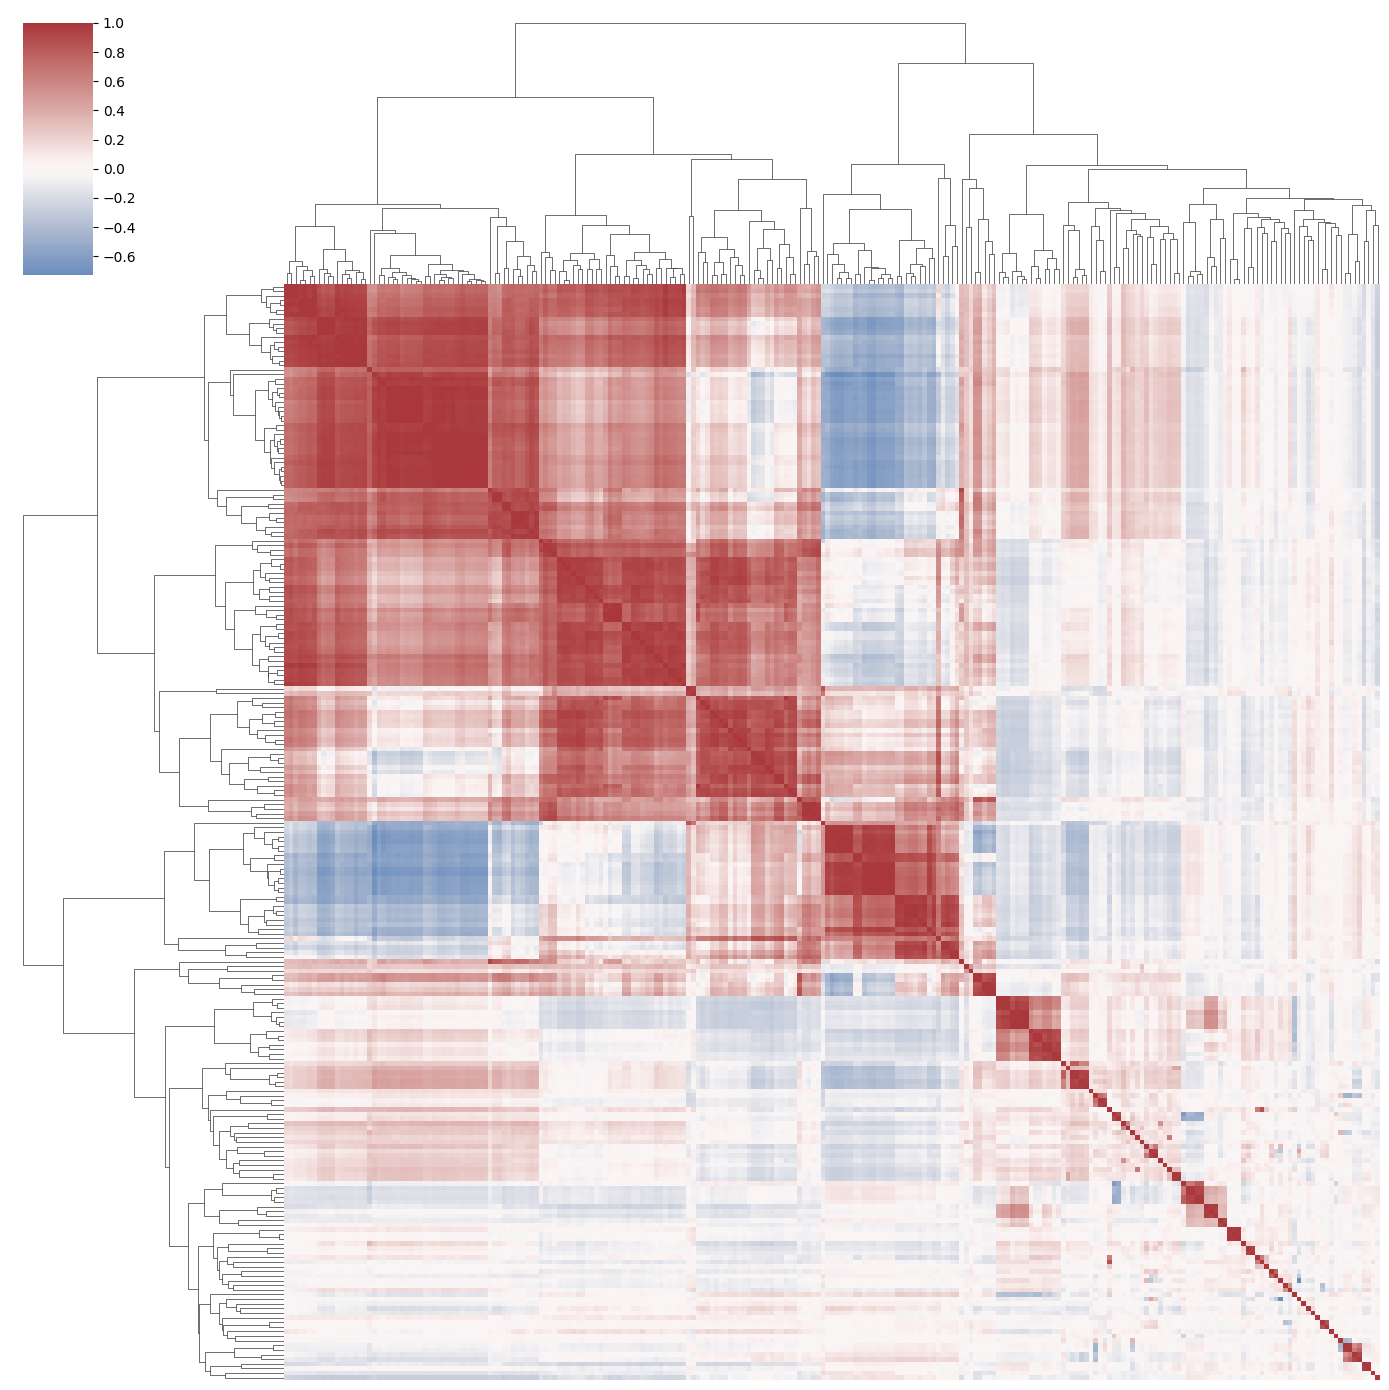

Continuous traits in correlation: 237


In [14]:
cont_traits = trait_kind.index[trait_kind == "continuous"].tolist()
cont = df[cont_traits].apply(pd.to_numeric, errors="coerce")
cont = cont.loc[:, cont.std() > 0]
corr = cont.corr(method="spearman")

order = sns.clustermap(corr, cmap="vlag", center=0, figsize=(14, 14),
                    xticklabels=False, yticklabels=False).dendrogram_row.reordered_ind
plt.show()
print(f"Continuous traits in correlation: {corr.shape[0]}")

In [15]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs["abs_r"] = pairs["spearman"].abs()
pairs.sort_values("abs_r", ascending=False).head(20)

,trait_a,trait_b,spearman,abs_r
4328,Cholesterol_in_Large_HDL,Cholesteryl_Esters_in_Large_HDL,0.996693,0.996693
27951,Weight_ANTHRO,Weight_IMPED,0.995728,0.995728
24767,Phospholipids_in_Very_Large_HDL,Total_Lipids_in_Very_Large_HDL,0.995723,0.995723
6246,Cholesterol_in_Very_Large_HDL,Cholesteryl_Esters_in_Very_Large_HDL,0.995678,0.995678
11445,Concentration_of_Large_HDL_Particles,Total_Lipids_in_Large_HDL,0.995634,0.995634
2766,Body_mass_index_BMI_ANTHRO,Body_mass_index_BMI_IMPED,0.995487,0.995487
23911,Phospholipids_in_Large_HDL,Total_Lipids_in_Large_HDL,0.995216,0.995216
13564,Concentration_of_Very_Small_VLDL_Particles,Total_Lipids_in_Very_Small_VLDL,0.994615,0.994615
4976,Cholesterol_in_Medium_HDL,Cholesteryl_Esters_in_Medium_HDL,0.994582,0.994582
12874,Concentration_of_Small_VLDL_Particles,Total_Lipids_in_Small_VLDL,0.994520,0.994520


## Cluster visualization

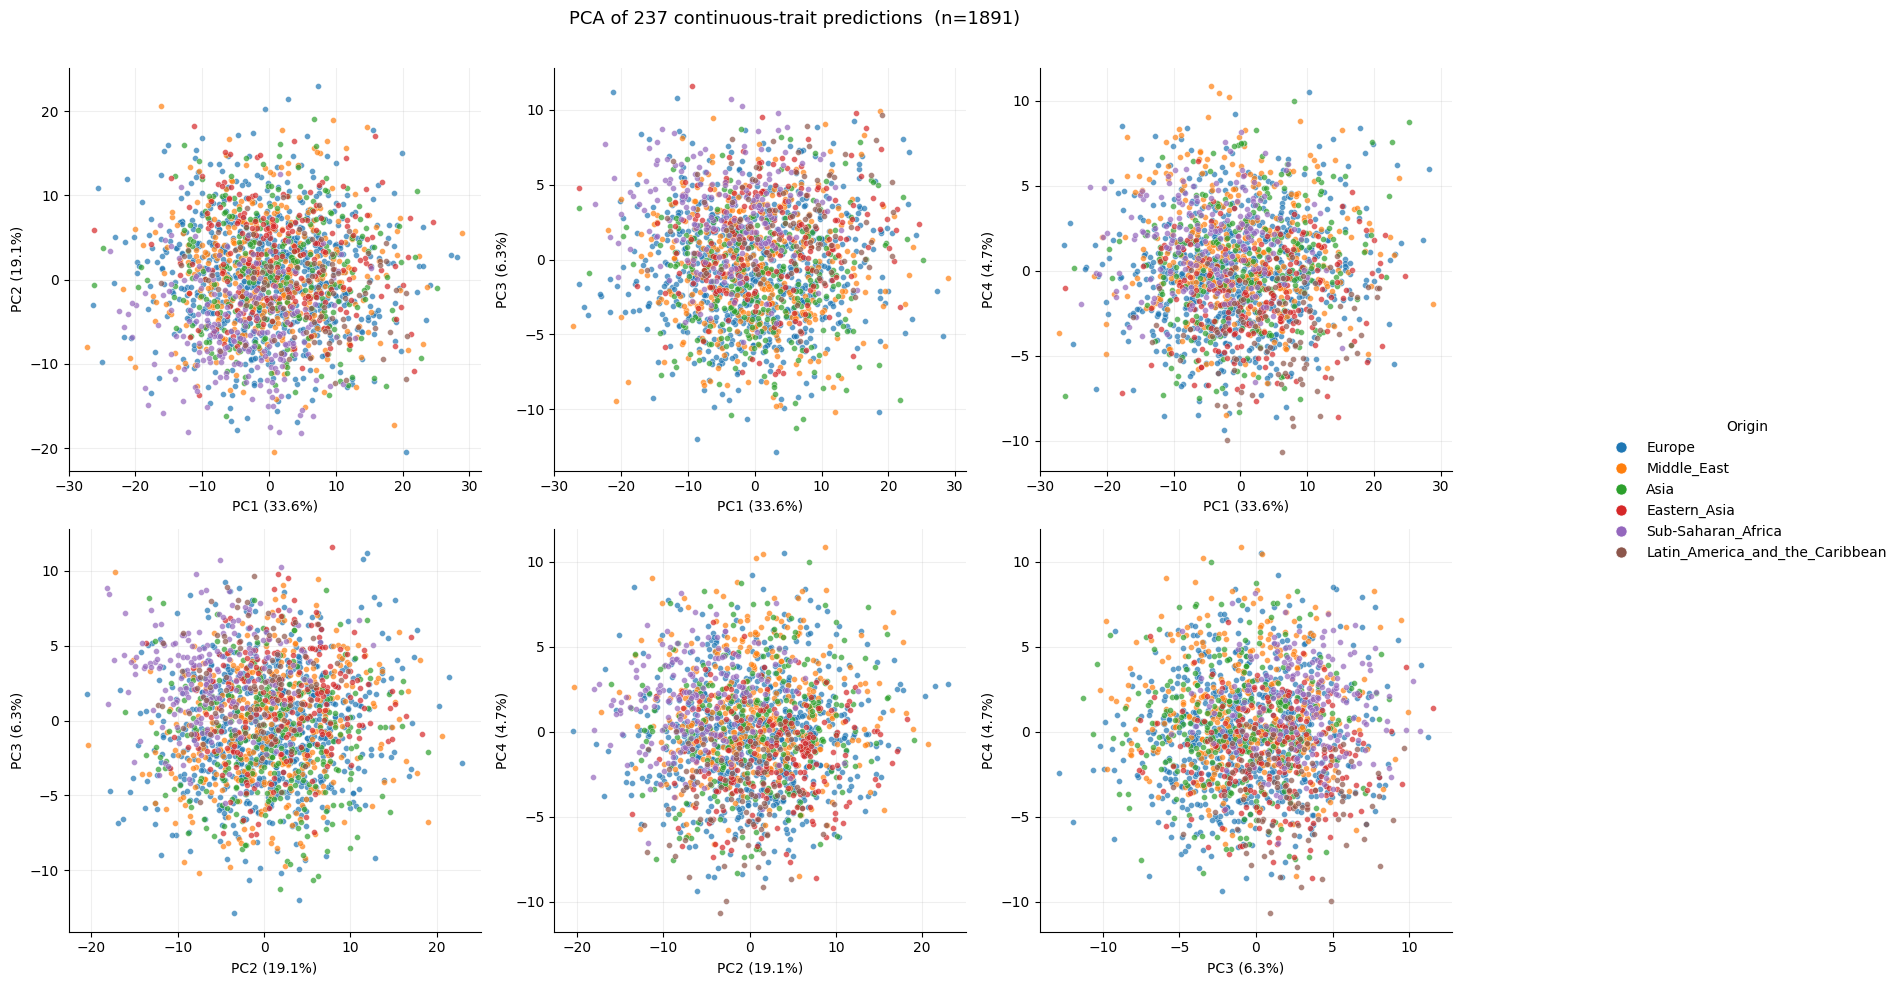

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations
import matplotlib.lines as mlines

X_df = df[cont.columns].dropna(axis=1, thresh=int(0.95 * len(df)))
X = StandardScaler().fit_transform(X_df.values)

origins = (df.loc[X_df.index, "Origin"]
           .value_counts().index.tolist()) 
palette = dict(zip(origins, sns.color_palette("tab10", n_colors=len(origins))))

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X)
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(4)], index=X_df.index)
pc_df["Origin"] = df.loc[X_df.index, "Origin"]

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (i, j) in zip(axes.flat, pairs):
  for origin in origins:
      sub = pc_df[pc_df["Origin"] == origin]
      ax.scatter(sub[f"PC{i}"], sub[f"PC{j}"],
                 s=18, alpha=0.7, linewidth=0.3,
                 edgecolor="white", color=palette[origin], label=origin)
  var_i, var_j = pca.explained_variance_ratio_[i-1], pca.explained_variance_ratio_[j-1]
  ax.set_xlabel(f"PC{i} ({var_i*100:.1f}%)")
  ax.set_ylabel(f"PC{j} ({var_j*100:.1f}%)")
  ax.spines[["top", "right"]].set_visible(False)
  ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", linestyle="",
                       markersize=8, markerfacecolor=palette[o],
                       markeredgecolor="white", markeredgewidth=0.5, label=o)
         for o in origins]
fig.legend(handles=handles, bbox_to_anchor=(1.0, 0.5), loc="center left",
         frameon=False, title="Origin")
fig.suptitle(f"PCA of {X_df.shape[1]} continuous-trait predictions  (n={len(pc_df)})",
           fontsize=13)
plt.tight_layout(rect=[0, 0, 0.92, 0.97])
plt.show()

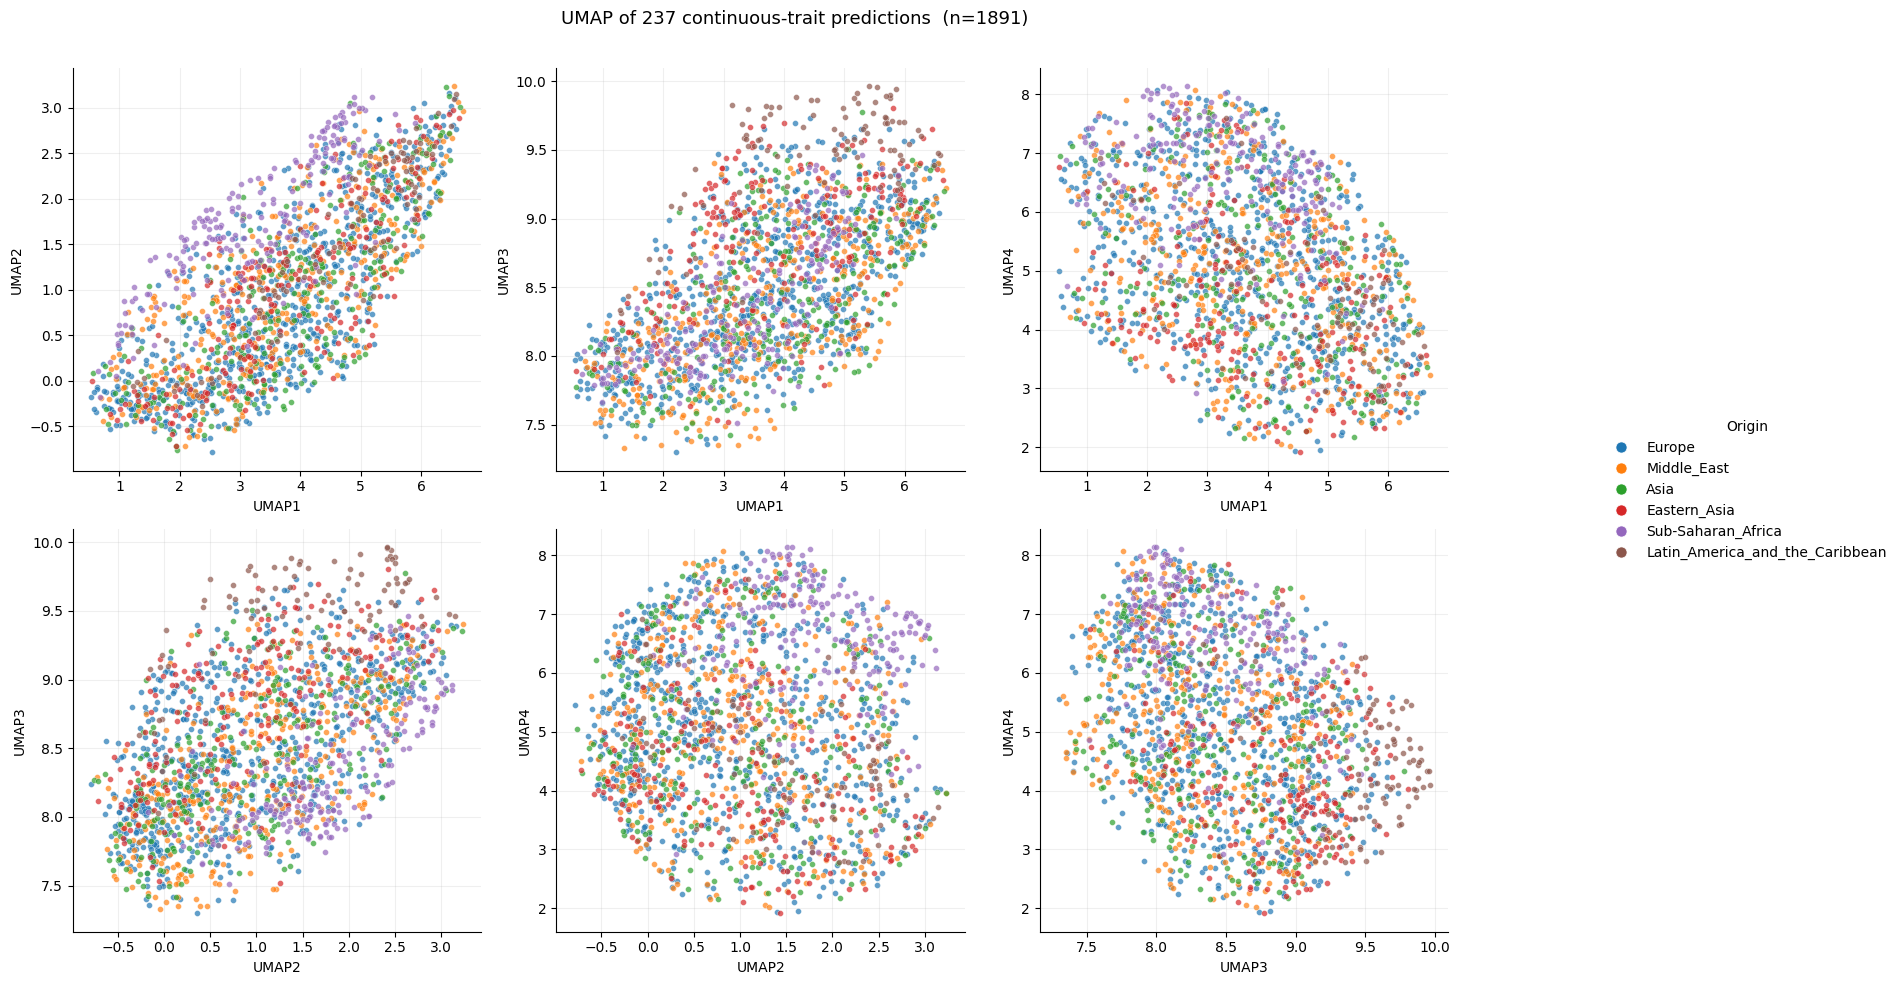

In [17]:
import umap

reducer = umap.UMAP(n_components=4, n_neighbors=30, min_dist=0.3,
                  metric="euclidean", random_state=0, n_jobs=1)
emb = reducer.fit_transform(X)
um_df = pd.DataFrame(emb, columns=[f"UMAP{i+1}" for i in range(4)], index=X_df.index)
um_df["Origin"] = df.loc[X_df.index, "Origin"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (i, j) in zip(axes.flat, pairs):
  for origin in origins:
      sub = um_df[um_df["Origin"] == origin]
      ax.scatter(sub[f"UMAP{i}"], sub[f"UMAP{j}"],
                 s=18, alpha=0.7, linewidth=0.3,
                 edgecolor="white", color=palette[origin], label=origin)
  ax.set_xlabel(f"UMAP{i}"); ax.set_ylabel(f"UMAP{j}")
  ax.spines[["top", "right"]].set_visible(False)
  ax.grid(alpha=0.2)

fig.legend(handles=handles, bbox_to_anchor=(1.0, 0.5), loc="center left",
         frameon=False, title="Origin")
fig.suptitle(f"UMAP of {X_df.shape[1]} continuous-trait predictions  (n={len(um_df)})",
           fontsize=13)
plt.tight_layout(rect=[0, 0, 0.92, 0.97])
plt.show()